## 1. Imports

In [1]:
import os, json, warnings, ssl, contextlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings("ignore")

ssl._create_default_https_context = ssl._create_unverified_context

import torch, torch.nn as nn, torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

torch.manual_seed(42); np.random.seed(42)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

USE_AMP = DEVICE.type == "cuda"
print(f"Device: {DEVICE}  |  AMP: {USE_AMP}")

def amp_ctx():
    return torch.amp.autocast("cuda") if USE_AMP else contextlib.nullcontext()

def make_scaler():
    return torch.amp.GradScaler("cuda") if USE_AMP else None

def backward(loss, opt, scaler=None):
    if scaler:
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
    else:
        loss.backward()
        opt.step()

Device: mps  |  AMP: False


## 2. Data Loading

In [2]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pyarrow as pa

PARQUET_FILES = ['../../QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet']
MAX_SAMPLES = 5000

def fast_load_parquet(paths, max_n=None):
    all_hr, all_lr, all_y = [], [], []
    for path in paths:
        print(f'Reading {path} ...')
        pf = pq.ParquetFile(path)
        names = pf.schema_arrow.names
        hr_col = next((c for c in names if 'X_jets' in c and 'LR' not in c.upper()), None)
        lr_col = next((c for c in names if 'X_jets' in c and 'LR'     in c.upper()), None)
        y_col  = next((c for c in names if c.lower() in ['y','label','pid','pdgid']), None)
        print(f'  HR={hr_col!r}  LR={lr_col!r}  y={y_col!r}')
        cols = [c for c in [hr_col, lr_col, y_col] if c]
        n_loaded = 0
        for batch in pf.iter_batches(batch_size=500, columns=cols):
            tbl = pa.Table.from_batches([batch])
            nrows = tbl.num_rows
            def flatten(col_name, dtype, is_img=True):
                col = tbl.column(col_name)
                if is_img:
                    while hasattr(col.type, 'value_type'): col = pc.list_flatten(col)
                    col = pc.cast(col, pa.float32())
                    return col.to_numpy(zero_copy_only=False).reshape(nrows, -1).astype(dtype, copy=False)
                return col.to_numpy(zero_copy_only=False).astype(dtype)
            if hr_col: all_hr.append(flatten(hr_col, np.float32))
            if lr_col: all_lr.append(flatten(lr_col, np.float32))
            if y_col:  all_y.append(flatten(y_col,  np.int32, is_img=False))
            del tbl, batch
            n_loaded += nrows
            print(f'  {n_loaded} events loaded...', end='\r')
            if max_n and n_loaded >= max_n: break
        print()
    slc = slice(None, max_n)
    Xhr = np.concatenate(all_hr)[slc]
    Xlr = np.concatenate(all_lr)[slc]
    y   = np.concatenate(all_y) [slc]
    def fix(a):
        if a.ndim == 2:
            n, tot = a.shape; side = int(round((tot/3)**0.5))
            a = a.reshape(n, side, side, 3)
        if a.ndim == 4 and a.shape[1] == 3: a = a.transpose(0,2,3,1)
        return a
    Xhr, Xlr = fix(Xhr), fix(Xlr)
    if not set(np.unique(y).tolist()).issubset({0,1}):
        lmap = {v:i for i,v in enumerate(sorted(np.unique(y).tolist()))}
        y = np.array([lmap[v] for v in y], dtype=np.int32)
    print(f'HR={Xhr.shape}  LR={Xlr.shape}  y={y.shape}')
    print(f'Class balance — 0:{(y==0).sum()}  1:{(y==1).sum()}')
    return Xhr, Xlr, y

X_hr_raw, X_lr_raw, y = fast_load_parquet(PARQUET_FILES, max_n=MAX_SAMPLES)


Reading ../../QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet ...
  HR='X_jets'  LR='X_jets_LR'  y='y'
  5000 events loaded...
HR=(5000, 125, 125, 3)  LR=(5000, 64, 64, 3)  y=(5000,)
Class balance — 0:2492  1:2508


## 3. EDA Visualizations

LR: (5000, 64, 64, 3)  HR: (5000, 125, 125, 3)
  Tracks (ch0): min=-4.150 max=986.863 mean=0.00523 nonzero=1.6%
  ECAL (ch1): min=-5.301 max=628.447 mean=0.00521 nonzero=1.6%
  HCAL (ch2): min=-3.070 max=478.619 mean=0.00523 nonzero=1.6%


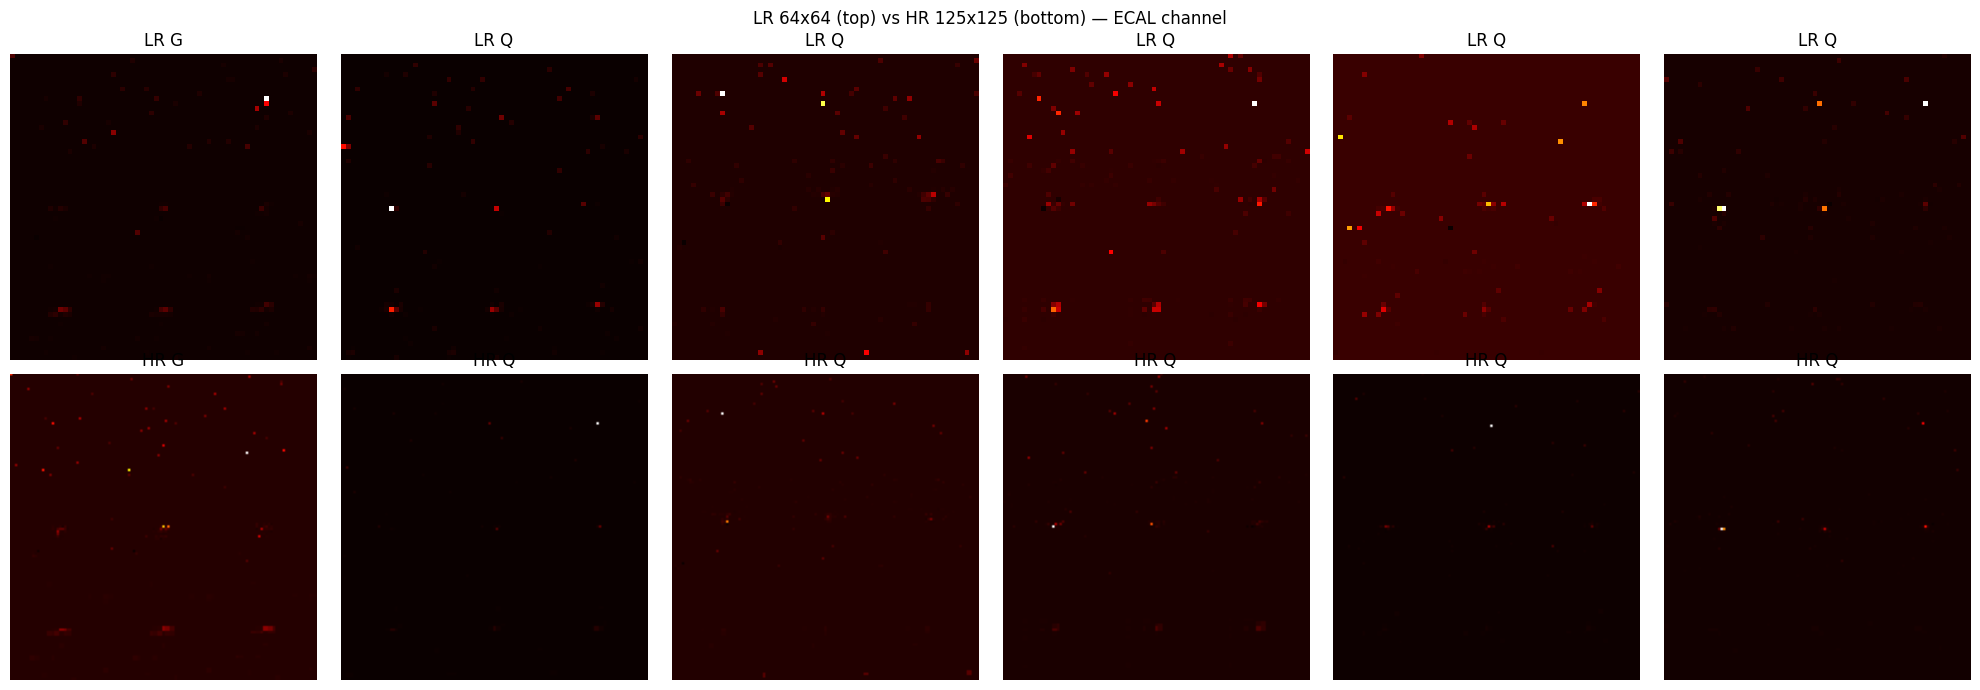

In [3]:
ch_names = ['Tracks (ch0)', 'ECAL (ch1)', 'HCAL (ch2)']
print(f'LR: {X_lr_raw.shape}  HR: {X_hr_raw.shape}')
for i,n in enumerate(ch_names):
    c2 = X_hr_raw[...,i].astype(float)
    print(f'  {n}: min={c2.min():.3f} max={c2.max():.3f} mean={c2.mean():.5f} nonzero={100*(c2>0).mean():.1f}%')

fig, axes = plt.subplots(2, 6, figsize=(20,7))
fig.suptitle('LR 64x64 (top) vs HR 125x125 (bottom) — ECAL channel', fontsize=12)
for col in range(6):
    idx = np.random.randint(len(X_hr_raw)); lbl='Q' if y[idx]==1 else 'G'
    axes[0,col].imshow(X_lr_raw[idx,...,1], cmap='hot'); axes[0,col].set_title(f'LR {lbl}'); axes[0,col].axis('off')
    axes[1,col].imshow(X_hr_raw[idx,...,1], cmap='hot'); axes[1,col].set_title(f'HR {lbl}'); axes[1,col].axis('off')
plt.tight_layout(); plt.savefig('eda_lr_hr.png', dpi=100); plt.show()


## 4. Preprocessing log1p + per-channel norm + CHW

In [4]:
def preprocess(X, ch_max=None):
    X = np.clip(X.astype(np.float32), 0, None)
    X = np.log1p(X)
    if ch_max is None:
        ch_max = np.array([X[...,i].max() for i in range(X.shape[-1])])
    for i in range(X.shape[-1]):
        if ch_max[i] > 0: X[...,i] /= ch_max[i]
    return X.transpose(0,3,1,2), ch_max

print('Preprocessing...')
X_hr, ch_max = preprocess(X_hr_raw.copy())
X_lr, _      = preprocess(X_lr_raw.copy(), ch_max)
print(f'HR: {X_hr.shape}  range [{X_hr.min():.3f}, {X_hr.max():.3f}]')
print(f'LR: {X_lr.shape}  range [{X_lr.min():.3f}, {X_lr.max():.3f}]')


Preprocessing...
HR: (5000, 3, 125, 125)  range [0.000, 1.000]
LR: (5000, 3, 64, 64)  range [0.000, 0.893]


## 5. Dataset & DataLoaders

In [5]:
idx_all = np.arange(len(X_hr))
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, random_state=42, stratify=y)
idx_va, idx_te  = train_test_split(idx_tmp, test_size=0.50, random_state=42, stratify=y[idx_tmp])
print(f"Train {len(idx_tr)} | Val {len(idx_va)} | Test {len(idx_te)}")

HR_SIZE, LR_SIZE = X_hr.shape[-1], X_lr.shape[-1]
print(f"LR={LR_SIZE}x{LR_SIZE}  HR={HR_SIZE}x{HR_SIZE}  (upsampling ~{HR_SIZE/LR_SIZE:.2f}x)")

class JetSRDataset(Dataset):
    def __init__(self, lr, hr, labels, idx):
        self.lr = torch.FloatTensor(lr[idx])
        self.hr = torch.FloatTensor(hr[idx])
        self.lb = torch.LongTensor(labels[idx])
    def __len__(self): return len(self.lr)
    def __getitem__(self, i): return self.lr[i], self.hr[i], self.lb[i]

BATCH = 32
train_ds = JetSRDataset(X_lr, X_hr, y, idx_tr)
val_ds   = JetSRDataset(X_lr, X_hr, y, idx_va)
test_ds  = JetSRDataset(X_lr, X_hr, y, idx_te)
train_loader = DataLoader(train_ds, BATCH, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  BATCH, shuffle=False, num_workers=0, pin_memory=False)
print(f"Dataloaders ready. {len(train_loader)} train batches.")


Train 3500 | Val 750 | Test 750
LR=64x64  HR=125x125  (upsampling ~1.95x)
Dataloaders ready. 110 train batches.


## 6. JEPA Architecture\nUsing a unified Context Encoder, Target Encoder, Predictor, and Decoder.

In [6]:
class ContextEncoder(nn.Module):
    def __init__(self, in_ch=3, nf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, nf, 3, 1, 1),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf, nf, 3, 2, 1), # downsample
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf, nf*2, 3, 2, 1), # downsample
            nn.LeakyReLU(0.2, True)
        )
    def forward(self, x): return self.net(x)

class TargetEncoder(nn.Module):
    def __init__(self, in_ch=3, nf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, nf, 4, 4, 1), # downsample from 125 to similar resolution
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(nf, nf*2, 3, 2, 1),
            nn.LeakyReLU(0.2, True)
        )
    def forward(self, x): return self.net(x)

class Predictor(nn.Module):
    def __init__(self, channels=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.LeakyReLU(0.2, True)
        )
    def forward(self, x): return self.net(x)

class Decoder(nn.Module):
    def __init__(self, in_ch=128, out_ch=3):
        super().__init__()
        nf = 64
        self.up = nn.Sequential(
            nn.Conv2d(in_ch, nf*4, 3, 1, 1), nn.PixelShuffle(2), nn.LeakyReLU(0.2,True),
            nn.Conv2d(nf, nf*4, 3, 1, 1), nn.PixelShuffle(2), nn.LeakyReLU(0.2,True),
            nn.Conv2d(nf, nf*4, 3, 1, 1), nn.PixelShuffle(2), nn.LeakyReLU(0.2,True),
            nn.Conv2d(nf, out_ch, 3, 1, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.up(x)[:, :, :HR_SIZE, :HR_SIZE]

class JEPAModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_lr = ContextEncoder()
        self.enc_hr = TargetEncoder()
        self.predictor = Predictor()
        self.decoder = Decoder()
        
    def forward(self, lr, hr=None):
        z_lr = self.enc_lr(lr)
        pred_z_hr = self.predictor(z_lr)
        sr = self.decoder(pred_z_hr)
        
        if hr is not None:
            with torch.no_grad():
                z_hr = self.enc_hr(hr)
            return sr, pred_z_hr, z_hr
        return sr

model = JEPAModel().to(DEVICE)
nparams = lambda m: sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'JEPA Model params: {nparams(model):,}')

with torch.no_grad():
    lr_t = torch.randn(2,3,LR_SIZE,LR_SIZE).to(DEVICE)
    hr_t = torch.randn(2,3,HR_SIZE,HR_SIZE).to(DEVICE)
    sr_t, p_t, z_t = model(lr_t, hr_t)
    print(f'LR: {lr_t.shape} -> SR: {sr_t.shape}')
    print(f'Predictor z: {p_t.shape} target z: {z_t.shape}')


JEPA Model params: 1,077,059
LR: torch.Size([2, 3, 64, 64]) -> SR: torch.Size([2, 3, 125, 125])
Predictor z: torch.Size([2, 128, 16, 16]) target z: torch.Size([2, 128, 16, 16])


## 7. Metrics & Validation

In [7]:
def batch_metrics(sr, hr):
    s = sr.cpu().detach().numpy().transpose(0,2,3,1)
    h = hr.cpu().detach().numpy().transpose(0,2,3,1)
    ps = [psnr_fn(h[i], s[i], data_range=1.0) for i in range(len(s))]
    ss = [ssim_fn(h[i], s[i], data_range=1.0, channel_axis=2, win_size=7) for i in range(len(s))]
    return np.mean(ps), np.mean(ss)

@torch.no_grad()
def validate(model, loader, nb=8):
    model.eval(); ps, ss = [], []
    for i, (lr_i, hr_i, _) in enumerate(loader):
        if i >= nb: break
        sr_i = model(lr_i.to(DEVICE))
        p, s = batch_metrics(sr_i, hr_i)
        ps.append(p); ss.append(s)
    model.train()
    return np.mean(ps), np.mean(ss)

print('Metrics ready.')


Metrics ready.


## 8. JEPA Training Loop (8 epochs)

In [8]:
N_EPOCHS = 8

scaler = make_scaler()
opt = optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)
hist = {"loss_pix":[], "loss_jepa":[], "vpsnr":[], "vssim":[]}
crit_pix = nn.L1Loss().to(DEVICE)
crit_jepa = nn.MSELoss().to(DEVICE)

print(f"=== JEPA Training ({N_EPOCHS} epochs) ===")
best_psnr = 0; model.train()

for ep in range(N_EPOCHS):
    el_pix, el_jepa = [], []
    pbar = tqdm(train_loader, desc=f"Epoch {ep+1}/{N_EPOCHS}", leave=False)
    for lr_i, hr_i, _ in pbar:
        lr_i, hr_i = lr_i.to(DEVICE), hr_i.to(DEVICE)
        opt.zero_grad()
        
        with amp_ctx():
            sr, pred_z, target_z = model(lr_i, hr_i)
            lp = crit_pix(sr, hr_i)
            lj = crit_jepa(pred_z, target_z.detach())
            loss = lp + 0.1 * lj
            
        backward(loss, opt, scaler)
        el_pix.append(lp.item())
        el_jepa.append(lj.item())
        pbar.set_postfix({"L1": f"{lp.item():.4f}", "JEPA": f"{lj.item():.4f}"})
        
    sched.step()
    vp, vs = validate(model, val_loader)
    hist['loss_pix'].append(np.mean(el_pix))
    hist['loss_jepa'].append(np.mean(el_jepa))
    hist['vpsnr'].append(vp)
    hist['vssim'].append(vs)
    
    print(f"Epoch {ep+1:02d}: L1={np.mean(el_pix):.4f} JEPA={np.mean(el_jepa):.4f} PSNR={vp:.2f}dB SSIM={vs:.4f}")
    if vp > best_psnr:
        best_psnr = vp
        torch.save(model.cpu().state_dict(), "jepa_best.pth")
        model.to(DEVICE)
        print(f"  ✓ Saved best (PSNR={best_psnr:.2f})")
print("JEPA training done!")


=== JEPA Training (8 epochs) ===


Epoch 01: L1=0.1216 JEPA=0.0940 PSNR=36.56dB SSIM=0.9501
  ✓ Saved best (PSNR=36.56)


Epoch 02: L1=0.0015 JEPA=0.0189 PSNR=40.42dB SSIM=0.9610
  ✓ Saved best (PSNR=40.42)


Epoch 03: L1=0.0009 JEPA=0.0086 PSNR=41.71dB SSIM=0.9633
  ✓ Saved best (PSNR=41.71)


Epoch 04: L1=0.0007 JEPA=0.0045 PSNR=42.38dB SSIM=0.9641
  ✓ Saved best (PSNR=42.38)


Epoch 05: L1=0.0006 JEPA=0.0031 PSNR=42.60dB SSIM=0.9644
  ✓ Saved best (PSNR=42.60)


Epoch 06: L1=0.0006 JEPA=0.0025 PSNR=42.68dB SSIM=0.9645
  ✓ Saved best (PSNR=42.68)


Epoch 07: L1=0.0006 JEPA=0.0022 PSNR=42.72dB SSIM=0.9645
  ✓ Saved best (PSNR=42.72)


Epoch 08: L1=0.0005 JEPA=0.0021 PSNR=42.72dB SSIM=0.9645
  ✓ Saved best (PSNR=42.72)
JEPA training done!


## 9. Training Curves

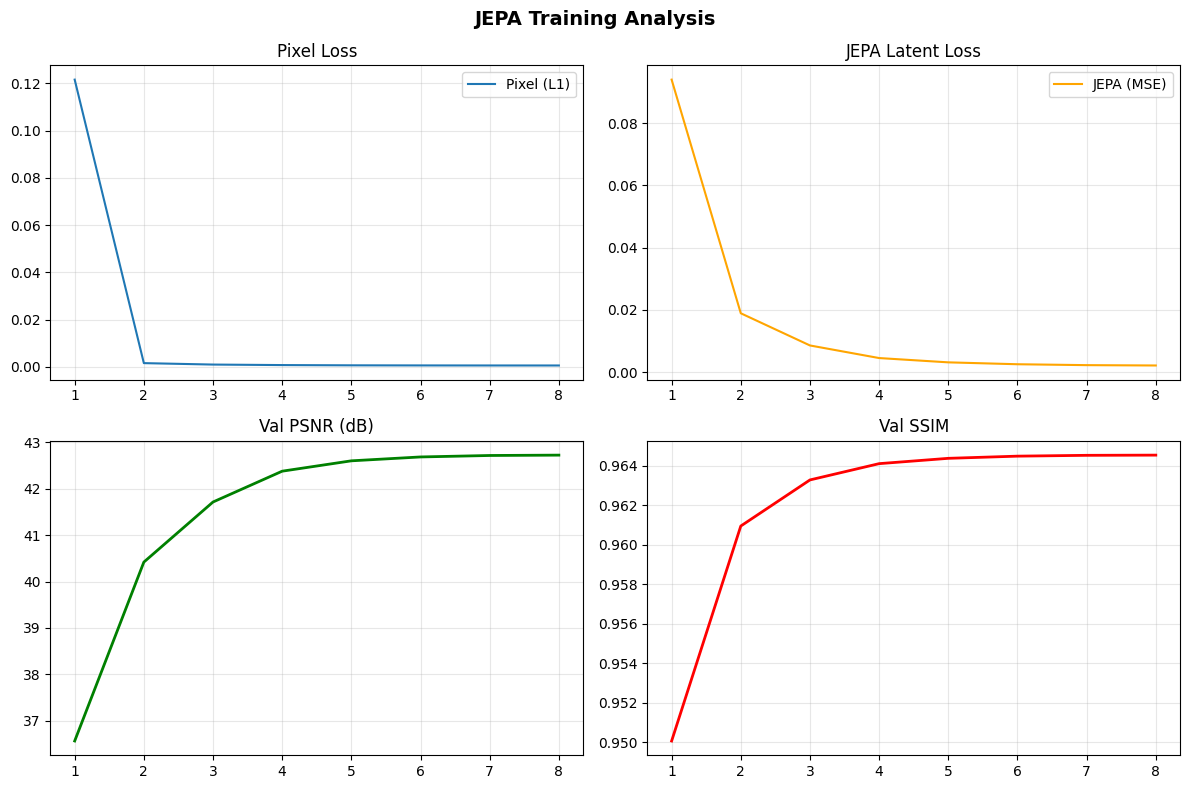

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
fig.suptitle('JEPA Training Analysis', fontsize=14, fontweight='bold')
ee = range(1, len(hist['vpsnr'])+1)
axes[0,0].plot(ee, hist['loss_pix'], label='Pixel (L1)'); axes[0,0].set_title('Pixel Loss'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,1].plot(ee, hist['loss_jepa'], label='JEPA (MSE)', color='orange'); axes[0,1].set_title('JEPA Latent Loss'); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)
axes[1,0].plot(ee, hist['vpsnr'], lw=2, color='green'); axes[1,0].set_title('Val PSNR (dB)'); axes[1,0].grid(alpha=0.3)
axes[1,1].plot(ee, hist['vssim'], lw=2, color='red'); axes[1,1].set_title('Val SSIM'); axes[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=120); plt.show()


## 10. Test Set Evaluation

In [10]:
ckpt = torch.load('jepa_best.pth', map_location=DEVICE)
model.load_state_dict(ckpt)
model.eval()
res = {k:[] for k in ['psnr','ssim','lbl']}

with torch.no_grad():
    for lr_i, hr_i, lb in tqdm(test_loader, desc='Test'):
        lr_i, hr_i = lr_i.to(DEVICE), hr_i.to(DEVICE)
        sr = model(lr_i)
        for i in range(len(lr_i)):
            p, s = batch_metrics(sr[i:i+1], hr_i[i:i+1])
            res['psnr'].append(p); res['ssim'].append(s); res['lbl'].append(lb[i].item())
res = {k: np.array(v) for k,v in res.items()}

print('\n' + '='*55)
print(f'  TEST SET (n={len(res["lbl"])})')
print('='*55)
print(f'  JEPA: PSNR={res["psnr"].mean():.3f}±{res["psnr"].std():.3f}  SSIM={res["ssim"].mean():.4f}±{res["ssim"].std():.4f}')
print('='*55)
for cl, name in [(1,'Quark'), (0,'Gluon')]:
    m2 = res['lbl']==cl
    print(f'  {name}: PSNR={res["psnr"][m2].mean():.3f}  SSIM={res["ssim"][m2].mean():.4f}')


Test:   0%|          | 0/24 [00:00<?, ?it/s]

Test: 100%|██████████| 24/24 [00:01<00:00, 12.74it/s]


  TEST SET (n=750)
  JEPA: PSNR=42.826±1.061  SSIM=0.9655±0.0082
  Quark: PSNR=42.772  SSIM=0.9669
  Gluon: PSNR=42.882  SSIM=0.9640


## 11. Visual Comparison — LR → JEPA → HR Truth

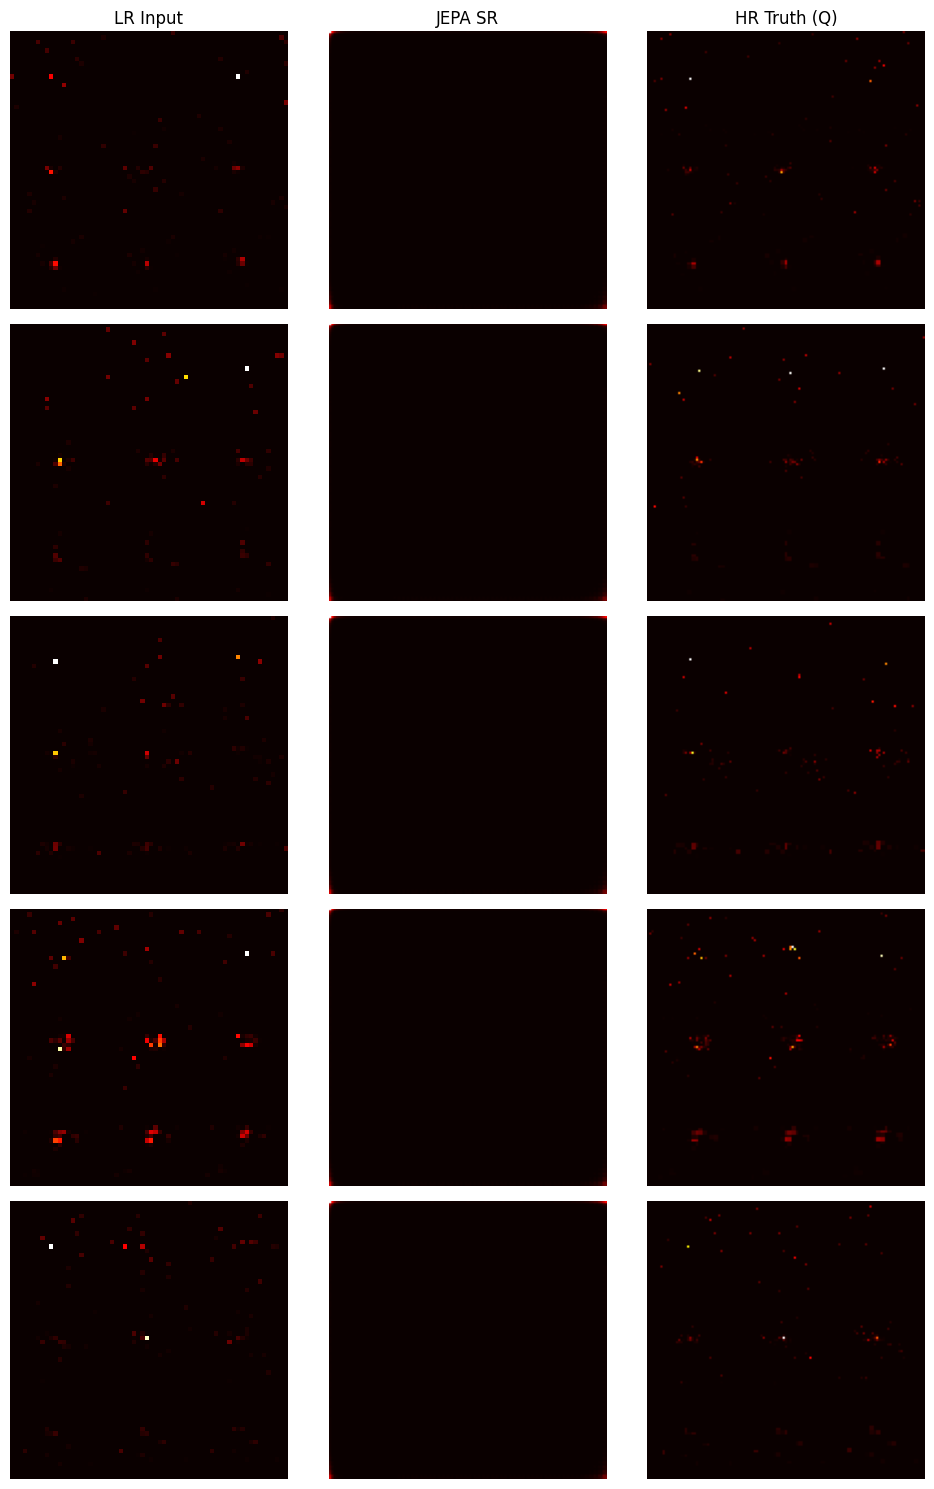

In [11]:
def show_comparison():
    model.eval()
    idx = np.random.choice(len(test_ds), 5, replace=False)
    fig, axes = plt.subplots(5, 3, figsize=(10, 15))
    for i, j in enumerate(idx):
        lr, hr, lb = test_ds[j]
        with torch.no_grad():
            sr = model(lr.unsqueeze(0).to(DEVICE))[0].cpu().detach().numpy().transpose(1,2,0)
        lr = lr.numpy().transpose(1,2,0)
        hr = hr.numpy().transpose(1,2,0)
        
        lbl = 'Q' if lb==1 else 'G'
        axes[i,0].imshow(lr[..., 1], cmap='hot'); axes[i,0].axis('off')
        if i==0: axes[i,0].set_title('LR Input')
        
        axes[i,1].imshow(sr[..., 1], cmap='hot'); axes[i,1].axis('off')
        if i==0: axes[i,1].set_title('JEPA SR')
        
        axes[i,2].imshow(hr[..., 1], cmap='hot'); axes[i,2].axis('off')
        if i==0: axes[i,2].set_title(f'HR Truth ({lbl})')

    plt.tight_layout(); plt.savefig('visual_comparison.png', dpi=150); plt.show()

show_comparison()
